# Lecture 6/ AA

### What is covered in this lecture

- **Data & setup:** Loading CRSP, Fama–French factors, and features; building a panel with **features_all** and target **fret10d** (10-day forward return).
- **Modeling & selection:** OLS, Lasso, forward selection; Fama–MacBeth estimation.
- **Appendix — building and preparing features:**
  - **Data** — panel structure, distributions, time series of target and features.
  - **De-noising** — rolling mean; feature correlation.
  - **Normalization** — z-score vs min-max.
  - **Box-Cox** — transformation in detail (λ, Q-Q plots).
  - **Correlation vs. Co-integration** — why co-integration matters for pairs trading on longer horizons; simulated examples and plots.
- **Predicting fret10d:** Comparison of **linear regression**, **non-linear (polynomial)** regression, and **machine learning** (Random Forest, Gradient Boosting) with train/test split and R² plots.



In [34]:
# after we install all the packages, import all of them for the use in today's lecture!
import platform
my_system = platform.uname()
print(f'My PC node: {my_system.node.lower()}')

# optimization
import cvxpy as cp

# storage and operations
import pandas as pd
import numpy as np
import datetime
from pathlib import Path
import joblib

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import linearmodels as lm

# import technical analysis 
import ta

# statistical analysis
from scipy import stats
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf, OAS

# set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('dark_background')
sns.set_palette("husl")

print('Packages imported successfully!')

My PC node: huangyikaidemacbook-pro.local
Packages imported successfully!


In [35]:
# we can specify some options depending on your computer
class Options:
    path = Path(r'/Users/huangyikai/Documents/FS SEM4/QT/')

print('Data Path: ',Options.path)

# some file names
class FileNames:
    fn_crsp = Options.path / 'crsp_original.parquet'
    fn_stock_features_labels = Options.path / 'stock_features.parquet'
    fn_option_features = Options.path / 'option_features_original.parquet'
    fn_ff_factors = Options.path / 'ff_factors.parquet'
    fn_sp500comp = Options.path / 'SP500_Index_Constitutes2024.csv'
    fn_universe = Options.path / 'permno_selection.csv'
    
    # Output files for portfolio optimization results
    fn_portfolio_weights = Options.path / 'portfolio_weights.parquet'
    fn_portfolio_performance = Options.path / 'portfolio_performance.parquet'

Data Path:  /Users/huangyikai/Documents/FS SEM4/QT


In [36]:
'''DEFINE FUNCTIONS TO LOAD THE DATA'''   
def load_ff_crsp():
    """Load Fama-French factors and CRSP stock returns"""
    crsp = pd.read_parquet(FileNames.fn_crsp)
    ff = pd.read_parquet(FileNames.fn_ff_factors)
    return crsp, ff   

# adjust the code to load the features adding the ones from option metrics
def load_features(crsp = True,
                 om = True, 
                  merge = True):
    features_crsp, features_om = pd.DataFrame(), pd.DataFrame()
    if crsp: 
        features_crsp = pd.read_parquet(FileNames.fn_stock_features_labels)
        features_crsp = features_crsp.sort_index()
        pass
    if om:
        features_om = pd.read_parquet(FileNames.fn_option_features)
        features_om = features_om.sort_index()
    if merge:
        res = pd.concat([features_crsp, features_om], axis = 1).sort_index()
    else:
        res = (features_crsp, features_om)
    return res

# Load the data
crsp, ff = load_ff_crsp()
features_crsp = load_features()

print(f"CRSP data shape: {crsp.shape}")
print(f"FF factors shape: {ff.shape}")
if not features_crsp.empty:
    print(f"Features shape: {features_crsp.shape}")

CRSP data shape: (1768460, 12)
FF factors shape: (7550, 7)
Features shape: (1776703, 18)


In [37]:
# copy-paste from Lecture 4 + adjust! 
def ols_est(X, Y, const = False):
    if const:
        X = sm.add_constant(X, has_constant="add")  # Ensure intercept
    model = sm.OLS(Y, X)
    results = model.fit()
    return results.params, results.rsquared_adj

def lasso_est(X, Y, alpha = 0.00001):
    lasso = Lasso(alpha = alpha).fit(X, Y)
    #print(lasso.coef_)
    return lasso.coef_

def make_prediction(X, model, linear=True):
    """
    Make predictions based on a given model.
    
    Parameters:
    - X: Feature matrix
    - model: Can be a fitted linear model (OLS, Lasso) or a non-linear model
    - linear: If True, assumes model is linear and expects `model` to be coefficients.
    
    Returns:
    - Predictions for X
    """
    if linear:
        return X @ model  # Matrix multiplication for linear models
    
    elif hasattr(model, "predict"):  
        return model.predict(X)  # Use .predict() where available/  for non-linear models
    
    else:
        raise ValueError("Unsupported model type: model must be linear coefficients or a fitted model with a `.predict()` method.")


In [38]:
def add_factor(X, Y, factors):
    """Find the best factor to add to the model based on adjusted R² improvement."""
    max_r2 = -1000
    max_col = None
    prm_max = None

    for col in X.columns:
        if col in factors:
            continue  # Skip already included factors
        prm, r2_adj = ols_est(X[factors + [col]], Y)
        if r2_adj > max_r2:
            max_col = col
            max_r2 = r2_adj
            prm_max = prm

    return (factors + [max_col]) if max_col else factors, prm_max, max_r2

def fwd_selection_est(X, Y):
    """Perform forward selection based on adjusted R², returning coefficients for all factors."""
    factors = []
    max_r2 = -1000
    r2_adj = -1000
    factors_new = []

    while True:
        new_factors, prm, new_r2 = add_factor(X, Y, factors)

        if new_r2 <= max_r2:  # Stop if adjusted R² does not improve
            break

        max_r2 = new_r2
        factors = new_factors

    # Initialize all coefficients as zero
    prm_res = pd.Series(0, index=X.columns, dtype=float)

    if factors:
        prm_selected, _ = ols_est(X[factors], Y)  # Fit final model with selected factors
        prm_res[factors] = prm_selected  # Assign selected factor coefficients

    return prm_res, max_r2


In [39]:
features_crsp = features_crsp.sort_index()
dates = sorted(list(features_crsp.index.levels[1].unique())[360:])
pred_horizon = 10
ret_var = f'fret{pred_horizon}d'
pred = {}
vars = ['mom12m',
       'mom6m', 'rev1m', 'glb', 'beta_mktrf', 'beta_smb', 'beta_hml',
       'beta_mom', 'idvar_ff4',
        'iv_atm', 
                 'put_skew', 
                 'call_skew']

features_crsp[ret_var] = features_crsp.groupby(level='permno')['ret'].rolling(window=pred_horizon). \
                        apply(lambda x: (x + 1).prod(), raw=True).reset_index(level=0)[['ret']] - 1

features_crsp[ret_var] = features_crsp.groupby(level='permno')[ret_var].shift(-pred_horizon)

features_crsp.dropna(inplace=True)
features_crsp.reset_index(inplace=True)
features_crsp.head()

,permno,date,ret,mktcap,mom12m,mom6m,rev1m,beta_mktrf,beta_smb,beta_hml,...,idvar_ff4,secid,iv_atm,put_skew,call_skew,put_skew_rel,call_skew_rel,overlap_start,overlap_end,fret10d
0,10104,2014-12-31,-0.008161,200915.32336,0.122049,0.016560,0.068678,1.141866,-0.269630,-0.541900,...,0.024360,108505.0,0.178476,0.055114,0.004481,0.308803,0.025105,1996-01-01,2024-12-31,-0.049427
1,10104,2015-01-02,-0.014232,197479.77399,0.113319,0.012509,0.050972,1.140102,-0.258900,-0.539181,...,0.024561,108505.0,0.182134,0.062998,-0.002216,0.345892,-0.012168,1996-01-01,2024-12-31,-0.015797
2,10104,2015-01-05,-0.013986,194669.29911,0.115964,0.017593,0.039230,1.123524,-0.252731,-0.542466,...,0.024600,108505.0,0.199347,0.058988,0.003852,0.295904,0.019325,1996-01-01,2024-12-31,0.007111
3,10104,2015-01-06,-0.010324,191419.68753,0.112789,0.005057,0.032675,1.124913,-0.251336,-0.540608,...,0.024602,108505.0,0.207479,0.055371,-0.002126,0.266873,-0.010244,1996-01-01,2024-12-31,0.008113
4,10104,2015-01-07,0.000232,189443.57238,0.108291,-0.011450,0.031929,1.116593,-0.245790,-0.519419,...,0.024808,108505.0,0.199981,0.0594,-0.003771,0.29703,-0.018856,1996-01-01,2024-12-31,0.020858


### Let us prepare our features/ think about the labels
- so far we mostly worked with linear models, but one can still easily add non-linear effects, e.g., squared features (or other degree), interactions, etc.
- we can easily compute multiple features using price, accounting, textual and other data -- e.g., technical analysis patterns.

In [40]:
df = features_crsp.set_index(['permno','date']).copy()
df.head()

ret        mktcap    mom12m     mom6m     rev1m  \
permno date                                                               
10104  2014-12-31 -0.008161  200915.32336  0.122049  0.016560  0.068678   
       2015-01-02 -0.014232  197479.77399  0.113319  0.012509  0.050972   
       2015-01-05 -0.013986  194669.29911  0.115964  0.017593  0.039230   
       2015-01-06 -0.010324  191419.68753  0.112789  0.005057  0.032675   
       2015-01-07  0.000232  189443.57238  0.108291 -0.011450  0.031929   

                   beta_mktrf  beta_smb  beta_hml  beta_mom  idvar_ff4  \
permno date                                                              
10104  2014-12-31    1.141866 -0.269630 -0.541900 -0.223871   0.024360   
       2015-01-02    1.140102 -0.258900 -0.539181 -0.221639   0.024561   
       2015-01-05    1.123524 -0.252731 -0.542466 -0.200264   0.024600   
       2015-01-06    1.124913 -0.251336 -0.540608 -0.201985   0.024602   
       2015-01-07    1.116593 -0.245790 -0.519419 -0.212445   0.024808   

                      secid    iv_atm  put_skew  call_skew  put_skew_rel  \
permno date                                                                
10104  2014-12-31  108505.0  0.178476  0.055114   0.004481      0.308803   
       2015-01-02  108505.0  0.182134  0.062998  -0.002216      0.345892   
       2015-01-05  108505.0  0.199347  0.058988   0.003852      0.295904   
       2015-01-06  108505.0  0.207479  0.055371  -0.002126      0.266873   
       2015-01-07  108505.0  0.199981    0.0594  -0.003771       0.29703   

                   call_skew_rel overlap_start overlap_end   fret10d  
permno date                                                           
10104  2014-12-31       0.025105    1996-01-01  2024-12-31 -0.049427  
       2015-01-02      -0.012168    1996-01-01  2024-12-31 -0.015797  
       2015-01-05       0.019325    1996-01-01  2024-12-31  0.007111  
       2015-01-06      -0.010244    1996-01-01  2024-12-31  0.008113  
       2015-01-07      -0.018856    1996-01-01  2024-12-31  0.020858

In [41]:
# define feature names -- initial selection
feature_names = ['mom12m',
                 'mom6m', 
                 'rev1m', 
                 'beta_mktrf', 
                 'beta_smb', 
                 'beta_hml', 
                 'beta_mom', 
                 'idvar_ff4',
                 'glb',
                 'iv_atm', 
                 'put_skew', 
                 'call_skew']

# we can define also some extra features, e.g.,
feature_for_sq = ['mom12m',
                 'mom6m',
                 'rev1m',
                 'beta_mktrf',
                 'beta_smb',
                 'beta_hml',
                 'beta_mom',
                 'iv_atm',
                 'put_skew',
                 'call_skew']

feature_sq = [f'{z}sq' for z in feature_for_sq]
df[feature_sq] = df[feature_for_sq]**2

feature_for_combos = [
                     'iv_atm',
                     'put_skew',
                     'call_skew']


df['constant'] = 1.0

In [42]:
features_all = ['mom12m', 'mom6m', 'rev1m',
       'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4',
       'iv_atm', 'put_skew', 'call_skew', 'put_skew_rel', 'call_skew_rel',
       'mom12msq', 'mom6msq',
       'rev1msq', 'beta_mktrfsq', 'beta_smbsq', 'beta_hmlsq', 'beta_momsq',
       'iv_atmsq', 'put_skewsq', 'call_skewsq'] # skew moment - very predictable

### Statistical problems / data preparation
 - Check how correlated are the resulting features -- do we have a problem? What can we do?
 - Can we put all the variables into a predictive model?

In [43]:
corr_all = df[['fret10d'] + features_all].corr()
print(corr_all.round(2))
hc = corr_all.abs()>0.2
corr_all[hc]
print(corr_all[hc].round(2))
# hc.sum()

               fret10d  mom12m  mom6m  rev1m  beta_mktrf  beta_smb  beta_hml  \
fret10d           1.00    0.00   0.02  -0.03        0.01      0.03      0.00   
mom12m            0.00    1.00   0.70  -0.01       -0.06      0.13     -0.01   
mom6m             0.02    0.70   1.00  -0.00       -0.03      0.07     -0.01   
rev1m            -0.03   -0.01  -0.00   1.00        0.01      0.02     -0.01   
beta_mktrf        0.01   -0.06  -0.03   0.01        1.00      0.36      0.20   
beta_smb          0.03    0.13   0.07   0.02        0.36      1.00      0.26   
beta_hml          0.00   -0.01  -0.01  -0.01        0.20      0.26      1.00   
beta_mom          0.01    0.27   0.16  -0.00       -0.20     -0.11     -0.05   
idvar_ff4         0.04    0.35   0.23   0.09        0.13      0.48      0.07   
iv_atm            0.07   -0.04  -0.05  -0.09        0.32      0.46      0.12   
put_skew          0.02   -0.04  -0.03  -0.00       -0.01      0.18      0.19   
call_skew         0.01   -0.03  -0.05  -

#### Let us see how well our unprocessed data predicts our labels (future returns for now)

In [44]:
minCRS = 50
idx = pd.IndexSlice
endogvar = ['fret10d']
exogvars = ['constant'] + features_all

# filter out too few CRS obs.
allvars = endogvar + exogvars
print(allvars)
data = df[allvars].copy()

# to make it faster just now, sample weekly
# data = data.groupby(['permno', pd.Grouper(level = 'date', freq='W-FRI')]).last()

# nobsCS = data.groupby('date').apply(lambda x: x.dropna().shape[0])
# obsCS = nobsCS.loc[nobsCS > minCRS].index
# data = data.loc[idx[:, obsCS], :]
# data[endogvar] = data.groupby(level='permno', group_keys=False)[endogvar].shift(-1)

res = lm.FamaMacBeth(data[endogvar],data[exogvars],check_rank=False).fit(cov_type='kernel', bandwidth=10)
res.summary

['fret10d', 'constant', 'mom12m', 'mom6m', 'rev1m', 'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4', 'iv_atm', 'put_skew', 'call_skew', 'put_skew_rel', 'call_skew_rel', 'mom12msq', 'mom6msq', 'rev1msq', 'beta_mktrfsq', 'beta_smbsq', 'beta_hmlsq', 'beta_momsq', 'iv_atmsq', 'put_skewsq', 'call_skewsq']


Dep. Variable:,fret10d,R-squared:,-0.9967
Estimator:,FamaMacBeth,R-squared (Between):,-3.2619
No. Observations:,1568762,R-squared (Within):,-0.9712
Date:,"Mon, Feb 16 2026",R-squared (Overall):,-0.9967
Time:,14:31:05,Log-likelihood,1.314e+06
Cov. Estimator:,Fama-MacBeth Kernel Cov,,
,,F-statistic:,-3.405e+04
Entities:,737,P-value,1.0000
Avg Obs:,2128.6,Distribution:,"F(23,1568738)"
Min Obs:,7.0000,,
Max Obs:,2507.0,F-statistic (robust):,2.5796


<Axes: xlabel='date'>

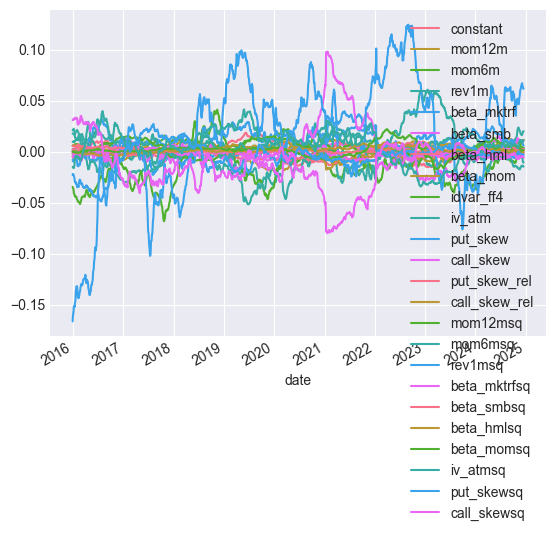

In [45]:
res.all_params.rolling(252).mean().plot()

---
## Appendix: Data, De-noising, Normalization, Box-Cox (for students)

This section uses the **same data** already loaded (`crsp`, `features_crsp`). **Features** = **features_all** (not all columns). **Target** = **fret10d** (10-day forward return).

### 1. Data — Overview and structure

**What is the data?** We work with a **panel**: one row per (date, permno). **Target** = **fret10d**. **Features** = **features_all** only (not all columns in features_crsp). Understanding the shape, time span, and distribution of these variables is the first step before any modeling.

In [46]:
# Appendix: use same data; features = features_all, target = fret10d
df_app = features_crsp.reset_index() if isinstance(features_crsp.index, pd.MultiIndex) else features_crsp.copy()
# Use only features_all (defined above), and only columns that exist
features_all = [c for c in features_all if c in df_app.columns]
target_col = 'fret10d'
print("Panel shape:", df_app.shape)
print("Date range:", df_app['date'].min(), "→", df_app['date'].max())
print("Features (features_all):", len(features_all), "|", "Target:", target_col)
df_app[features_all[:6] + [target_col]].describe()

Panel shape: (1568762, 21)
Date range: 2014-12-31 00:00:00 → 2024-12-16 00:00:00
Features (features_all): 13 | Target: fret10d


,mom12m,mom6m,rev1m,beta_mktrf,beta_smb,beta_hml,fret10d
count,1.568762e+06,1.568762e+06,1.568762e+06,1.568762e+06,1.568762e+06,1.568762e+06,1.568762e+06
mean,1.493823e-01,7.063963e-02,1.220652e-02,9.985572e-01,1.584260e-01,1.669319e-01,5.670968e-03
std,5.935769e-01,3.123163e-01,1.064019e-01,3.417483e-01,4.700360e-01,5.747761e-01,7.410707e-02
min,-9.826872e-01,-9.524038e-01,-9.079685e-01,-5.664807e+00,-5.907654e+00,-4.500382e+00,-9.020771e-01
25%,-7.783712e-02,-6.990613e-02,-3.868301e-02,7.860632e-01,-1.472967e-01,-1.860444e-01,-2.749495e-02
50%,1.063772e-01,5.708518e-02,1.139975e-02,9.912520e-01,7.954256e-02,1.247231e-01,5.882243e-03
75%,3.016825e-01,1.845317e-01,6.058676e-02,1.201480e+00,3.671890e-01,4.835679e-01,3.835818e-02
max,8.169745e+01,8.720057e+01,1.624615e+01,3.627100e+00,8.985128e+00,4.280221e+00,1.641904e+01


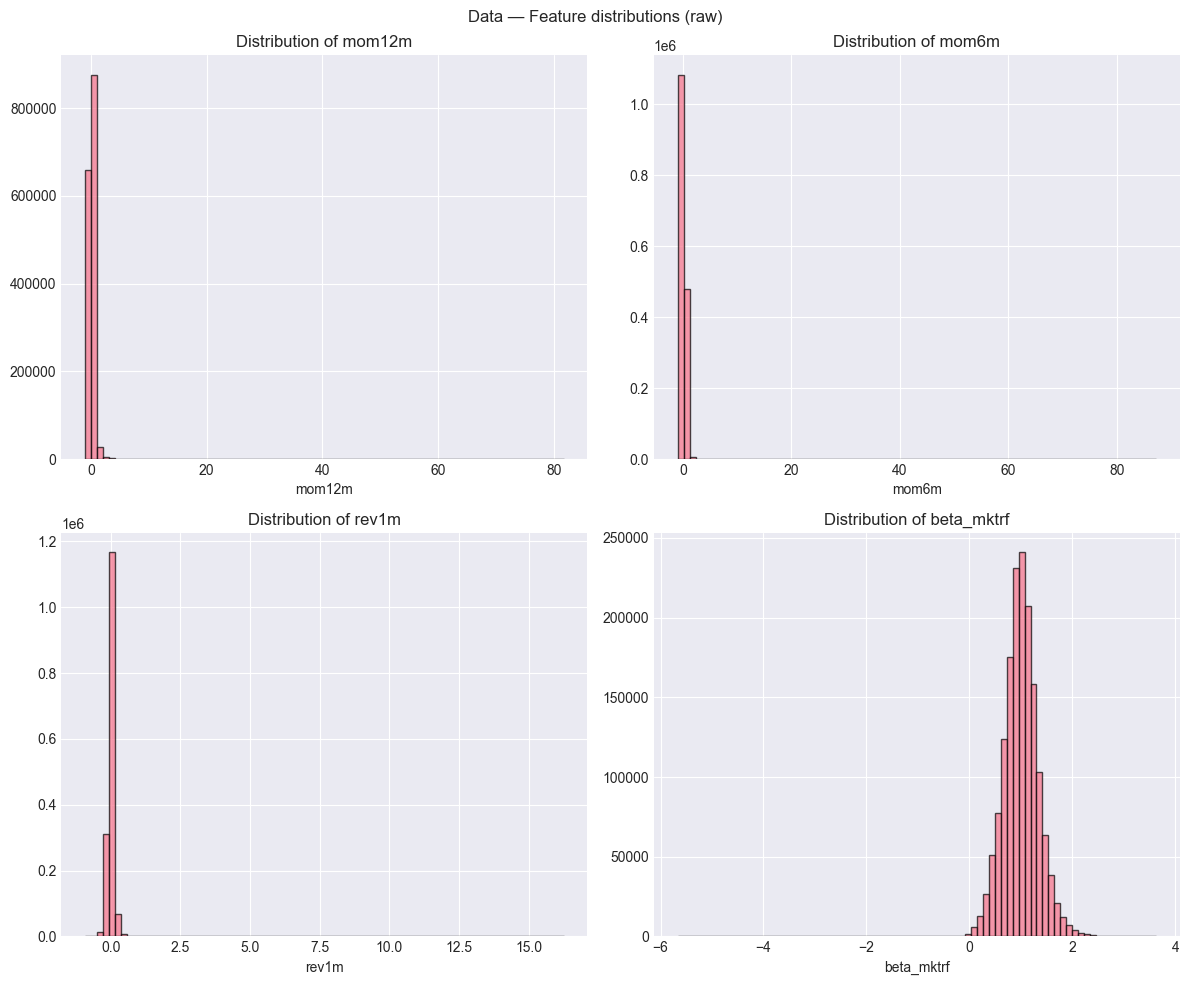

In [71]:
# Data: distributions of a few features and time series of cross-sectional average return
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Sample one feature distribution
for i, col in enumerate(features_all[:4]):
    ax = axes.flat[i]
    df_app[col].dropna().hist(ax=ax, bins=80, alpha=0.7, edgecolor='k')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.suptitle('Data — Feature distributions (raw)', fontsize=12)
plt.tight_layout()
plt.show()

CHECK THIS BEFORE U DO ANY TRANSFORMATION TO SEE THE STURUCTURE

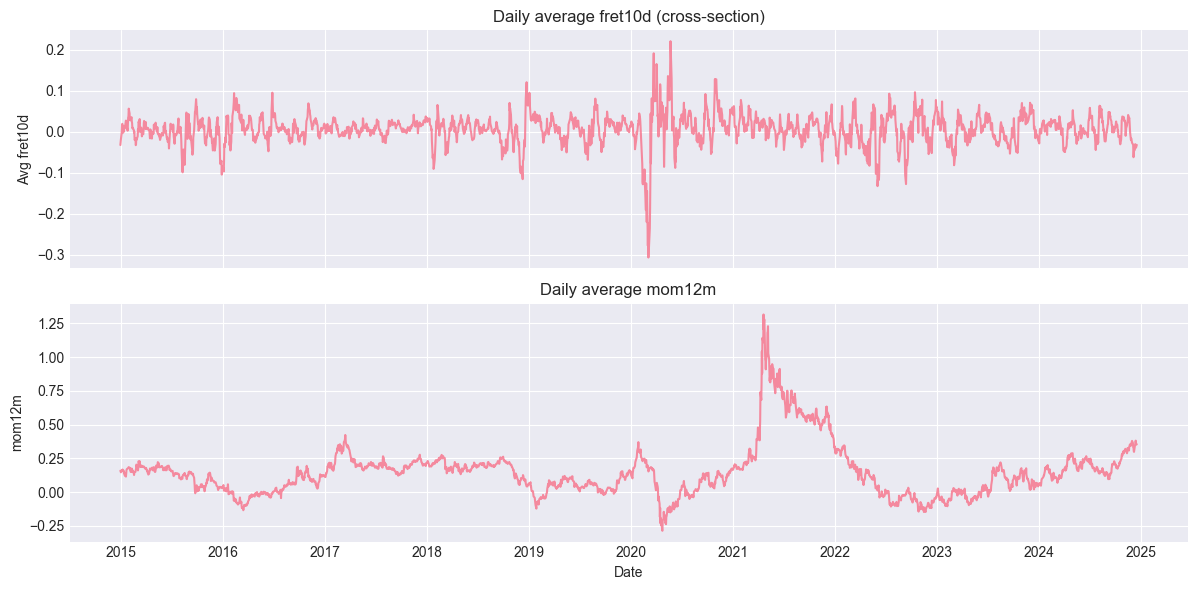

In [48]:
# Time series: cross-sectional average return and one feature over time
daily_target = df_app.groupby('date')[target_col].mean()
f0 = features_all[0]
daily_f = df_app.groupby('date')[f0].mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(np.asarray(daily_target.index), np.asarray(daily_target.values), alpha=0.8)
axes[0].set_ylabel('Avg ' + target_col); axes[0].set_title('Daily average ' + target_col + ' (cross-section)')
axes[1].plot(np.asarray(daily_f.index), np.asarray(daily_f.values), alpha=0.8)
axes[1].set_ylabel(f0); axes[1].set_xlabel('Date'); axes[1].set_title(f'Daily average {f0}')
plt.tight_layout()
plt.show()

### 2. De-noising

**Why?** Raw features are often noisy. **De-noising** reduces high-frequency noise so the signal is easier to use for prediction. A simple method is a **rolling mean** (moving average) over time for each stock: we replace each value with the average of the last \(w\) observations.

**Trade-off:** Larger window \(w\) → smoother series but more lag; smaller \(w\) → more reactive but noisier.

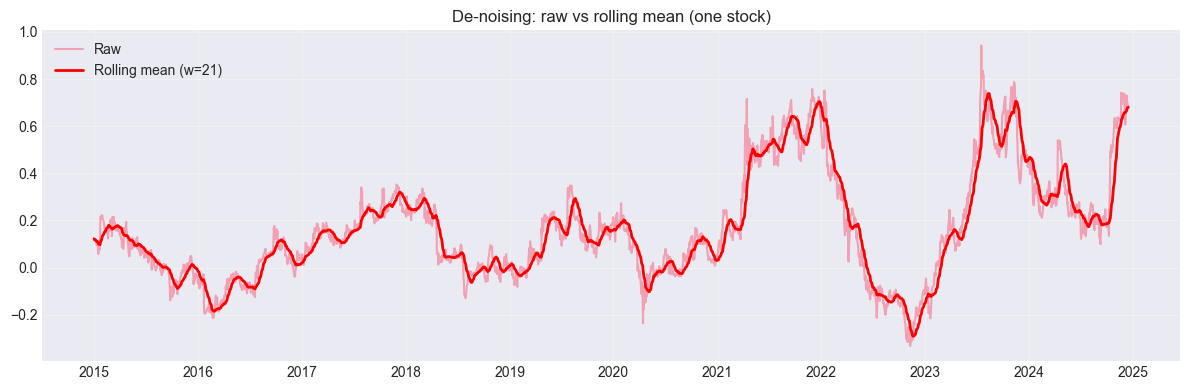

In [49]:
# De-noising: raw vs rolling mean for one stock, one feature
win = 21
df_s = df_app.sort_values(['permno', 'date']).copy()
df_s['f_rolling'] = df_s.groupby('permno')[f0].transform(lambda x: x.rolling(win, min_periods=1).mean())
one = df_s[df_s['permno'] == df_s['permno'].iloc[0]].set_index('date')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.asarray(one.index), np.asarray(one[f0]), alpha=0.6, label='Raw')
ax.plot(np.asarray(one.index), np.asarray(one['f_rolling']), color='red', lw=2, label=f'Rolling mean (w={win})')
ax.set_title('De-noising: raw vs rolling mean (one stock)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CAN HAVE PREDICT POWER!!!

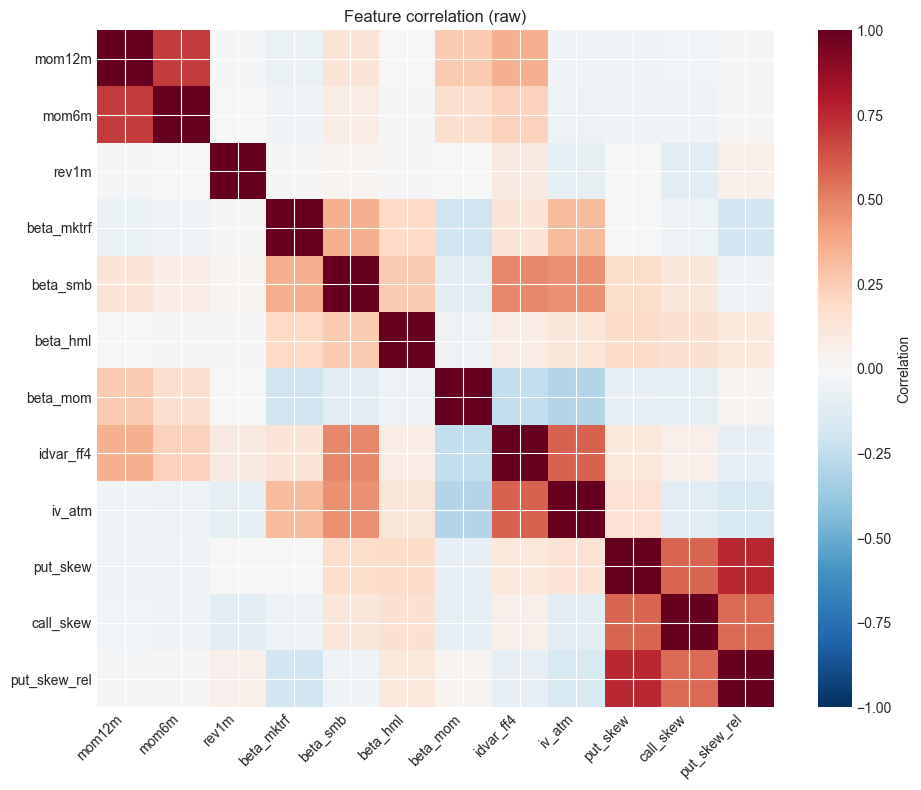

In [50]:
# Feature correlation matrix (subset) — high correlation suggests redundancy or need for de-noising / regularization
corr = df_app[features_all[:12]].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Feature correlation (raw)')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

### 3. Normalization

**Why?** Features live on different scales (e.g. returns in [-0.1, 0.1] vs market cap in millions). Many algorithms (e.g. OLS, gradient descent) behave better when inputs are on a comparable scale.

- **Z-score (standardization):** subtract mean, divide by standard deviation → mean 0, variance 1.
- **Min-max:** scale to a fixed interval (e.g. [0, 1]) using min and max of the data.

**Important:** Fit the scaler on the **training** set only, then apply the same transformation to the test set to avoid look-ahead bias.

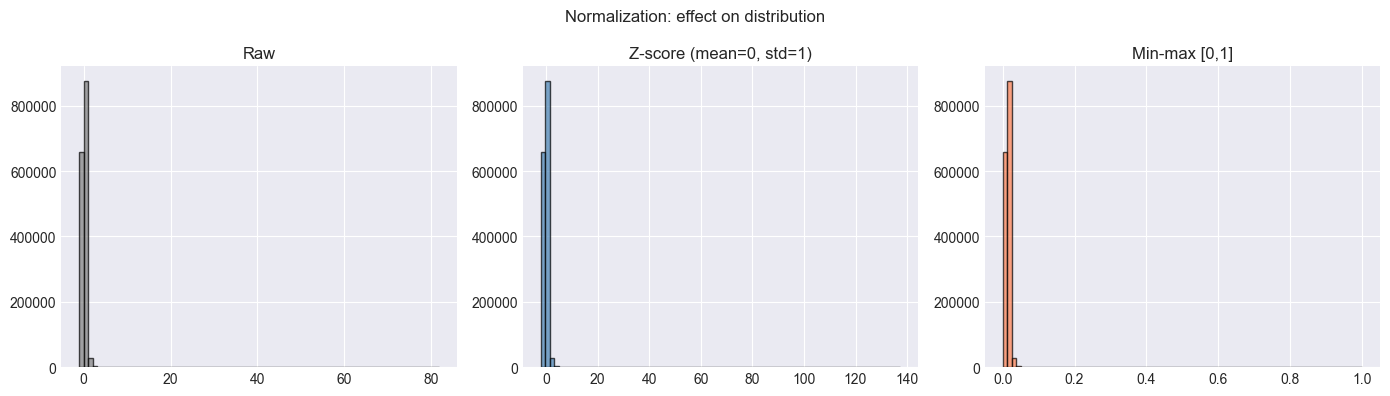

In [51]:
# Normalization: z-score vs min-max on one feature
from sklearn.preprocessing import StandardScaler, MinMaxScaler
x = df_app[f0].fillna(0).values.reshape(-1, 1)
zscore = StandardScaler().fit_transform(x).ravel()
minmax = MinMaxScaler(feature_range=(0, 1)).fit_transform(x).ravel()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(x.ravel(), bins=80, alpha=0.7, color='gray', edgecolor='k')
axes[0].set_title('Raw')
axes[1].hist(zscore, bins=80, alpha=0.7, color='steelblue', edgecolor='k')
axes[1].set_title('Z-score (mean=0, std=1)')
axes[2].hist(minmax, bins=80, alpha=0.7, color='coral', edgecolor='k')
axes[2].set_title('Min-max [0,1]')
plt.suptitle('Normalization: effect on distribution')
plt.tight_layout()
plt.show()

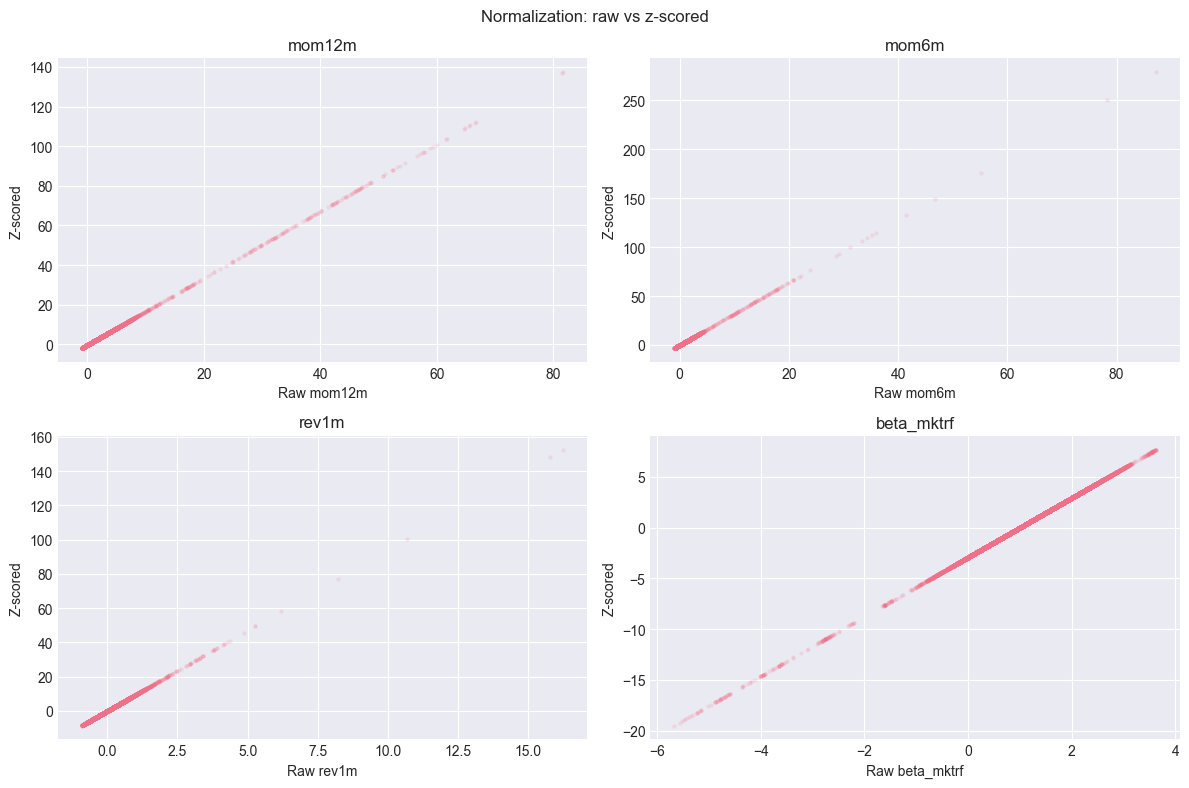

In [52]:
# Compare scales: raw vs z-scored (first 4 features)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(features_all[:4]):
    ax = axes.flat[i]
    raw = df_app[col].dropna()
    z = StandardScaler().fit_transform(df_app[[col]].fillna(0)).ravel()
    ax.scatter(raw, z, alpha=0.1, s=5)
    ax.set_xlabel(f'Raw {col}')
    ax.set_ylabel('Z-scored')
    ax.set_title(col)
plt.suptitle('Normalization: raw vs z-scored')
plt.tight_layout()
plt.show()

### 4. Box-Cox transformation in detail

**What is it?** The Box-Cox transformation is \(y^{(\lambda)} = \frac{y^\lambda - 1}{\lambda}\) for \(\lambda \neq 0\), and \(\ln(y)\) for \(\lambda = 0\). It is defined only for **positive** data.

**Why use it?** It can make skewed distributions more symmetric and stabilize variance, which helps meet normality assumptions in linear models and improves stability of optimization.

**Parameter λ:** We choose \(\lambda\) (e.g. by maximum likelihood) to make the transformed data as close to normal as possible. Common special cases: \(\lambda = 1\) (no change), \(\lambda = 0.5\) (square root), \(\lambda = 0\) (log).

Box-Cox optimal λ = -0.0181


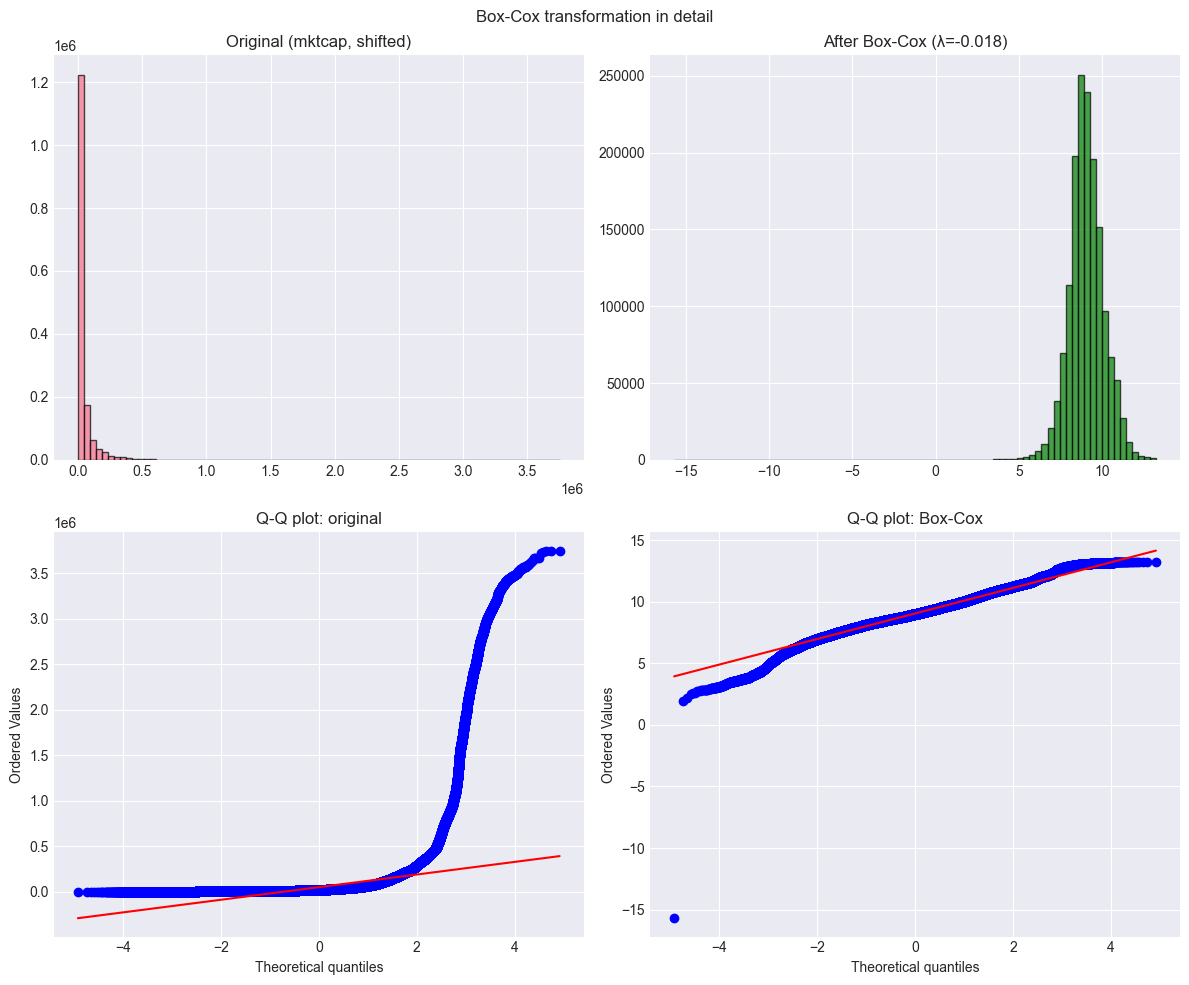

In [53]:
# Box-Cox: need strictly positive data — shift so all values > 0
from scipy.stats import boxcox
col_bc = 'mktcap' if 'mktcap' in df_app.columns else features_all[0]
series = df_app[col_bc].dropna()
x_pos = series - series.min() + 1e-6  # ensure x_pos > 0
bc, lam = boxcox(x_pos)
print(f"Box-Cox optimal λ = {lam:.4f}")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].hist(x_pos, bins=80, alpha=0.7, edgecolor='k')
axes[0, 0].set_title(f'Original ({col_bc}, shifted)')
axes[0, 1].hist(bc, bins=80, alpha=0.7, color='green', edgecolor='k')
axes[0, 1].set_title(f'After Box-Cox (λ={lam:.3f})')
# Q-Q plots
stats.probplot(x_pos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot: original')
stats.probplot(bc, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot: Box-Cox')
plt.suptitle('Box-Cox transformation in detail')
plt.tight_layout()
plt.show()

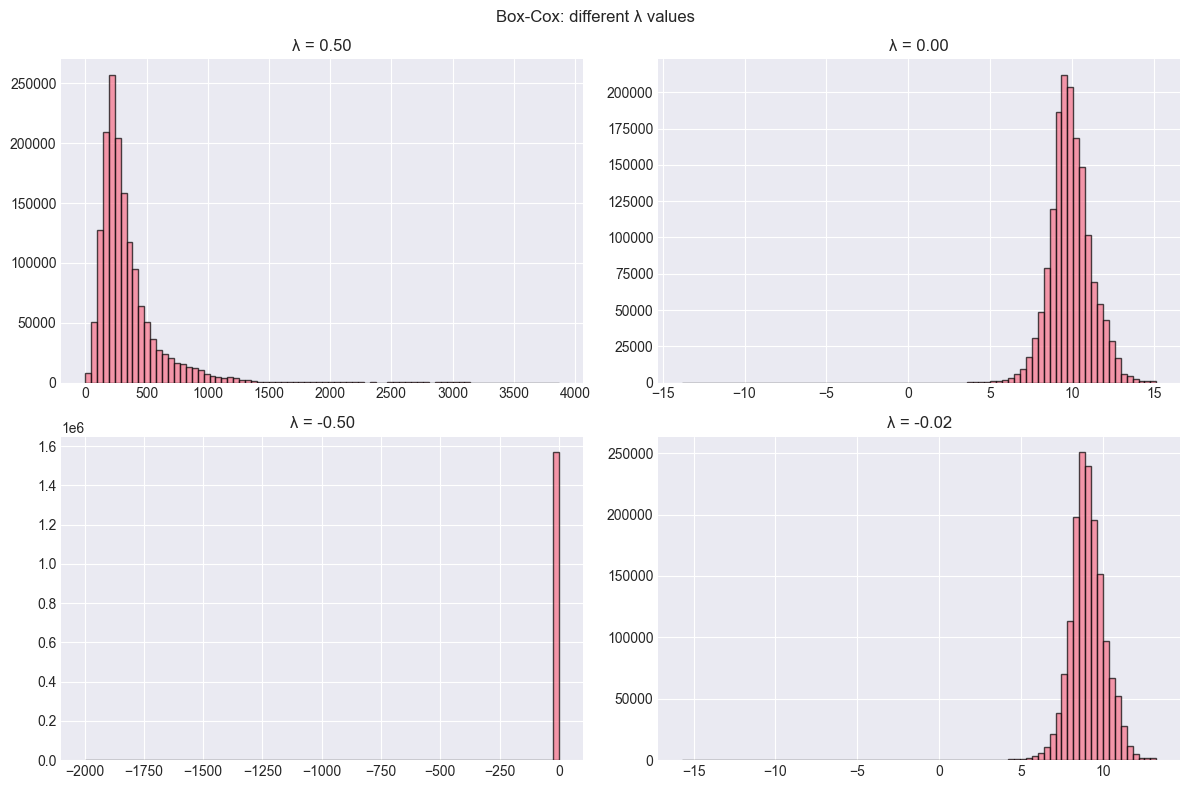

In [54]:
# Box-Cox: effect of different λ values (same positive series)
def boxcox_manual(y, lam):
    y = np.asarray(y)
    if abs(lam) < 1e-10:
        return np.log(y)
    return (np.power(y, lam) - 1) / lam
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
lambdas = [0.5, 0.0, -0.5, lam]
for i, l in enumerate(lambdas):
    ax = axes.flat[i]
    t = boxcox_manual(x_pos, l)
    ax.hist(t, bins=80, alpha=0.7, edgecolor='k')
    ax.set_title(f'λ = {l:.2f}')
plt.suptitle('Box-Cox: different λ values')
plt.tight_layout()
plt.show()

**Recap for students**

| Topic | Purpose |
|-------|--------|
| **Data** | Panel (date × permno). Features = **features_all**; target = **fret10d**. Inspect shape, ranges, distributions. |
| **De-noising** | Reduce noise (e.g. rolling mean); check correlation structure. |
| **Normalization** | Put features on a common scale (z-score or min-max); fit on train only. |
| **Box-Cox** | Transform positive, skewed data toward normality; choose λ (e.g. by MLE). |
| **Correlation vs. Co-integration** | Correlation ≠ cointegration. For pairs trading on longer horizons, use cointegration so the spread mean-reverts. |

### 5. Correlation vs. Co-integration

**Correlation** measures *linear association* between two series at a point in time (or over a window). It can be high even when the series drift apart over time (e.g. two random walks).

**Co-integration** means two (or more) non-stationary series have a *stationary linear combination* — i.e. a **spread** that mean-reverts. So the long-run relationship is stable even though each series is trending.

**Why it matters in finance:** For **pairs trading** or **relative-value strategies** on longer horizons, we need the spread to mean-revert. Correlation alone does not guarantee that: two correlated assets can diverge forever. Co-integration tells us we can trade one asset against the other (long one, short the other) and expect the spread to revert, reducing directional risk. Below we use **simulated data** to illustrate the difference.

In [55]:
# Simulated data: cointegrated pair vs correlated-but-not-cointegrated pair
np.random.seed(42)
T = 500
# --- Cointegrated pair: A and B share a common trend; spread is stationary ---
trend = np.cumsum(np.random.randn(T) * 0.5)  # common trend (random walk)
spread_stationary = np.zeros(T)
for t in range(1, T):
    spread_stationary[t] = 0.85 * spread_stationary[t-1] + np.random.randn() * 0.25  # AR(1) mean-reverting
A = trend + spread_stationary
B = trend - spread_stationary
# --- Correlated but NOT cointegrated: two random walks (high correlation in sample, spread diverges) ---
C = np.cumsum(np.random.randn(T) * 0.5)
D = np.cumsum(np.random.randn(T) * 0.5)
t_idx = np.arange(T)

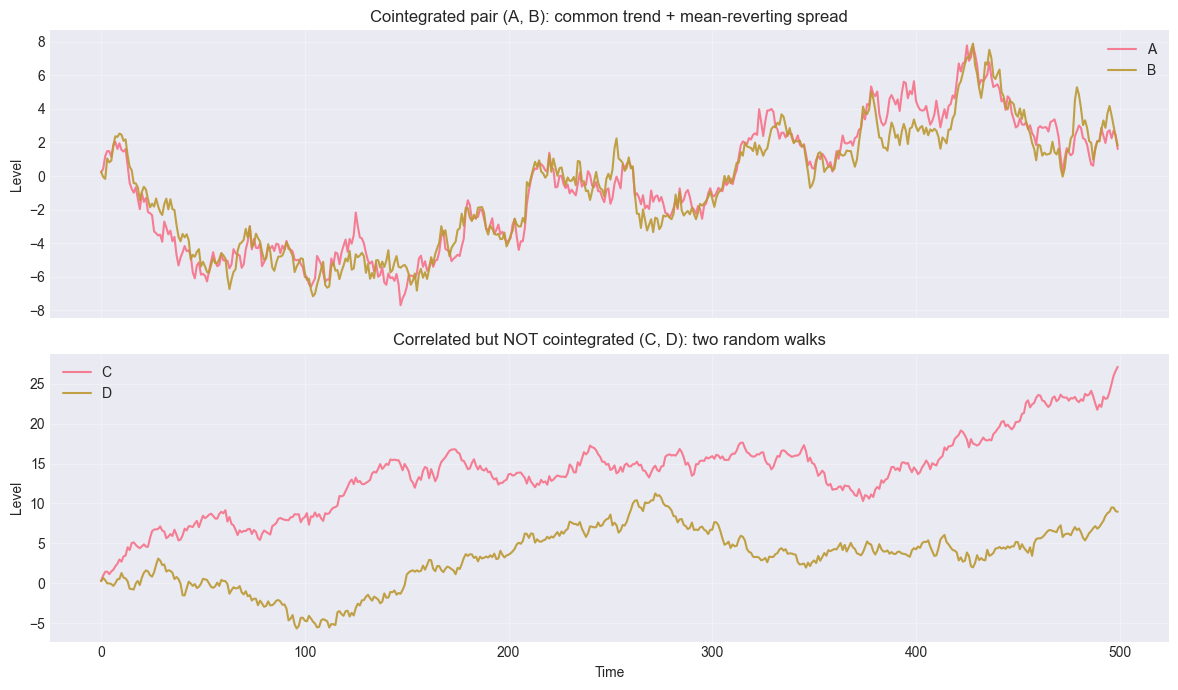

In [56]:
# Graph 1: Cointegrated pair (A, B) vs Correlated-but-not-cointegrated pair (C, D)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(t_idx, A, label='A', alpha=0.9)
axes[0].plot(t_idx, B, label='B', alpha=0.9)
axes[0].set_ylabel('Level')
axes[0].set_title('Cointegrated pair (A, B): common trend + mean-reverting spread')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_idx, C, label='C', alpha=0.9)
axes[1].plot(t_idx, D, label='D', alpha=0.9)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Level')
axes[1].set_title('Correlated but NOT cointegrated (C, D): two random walks')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

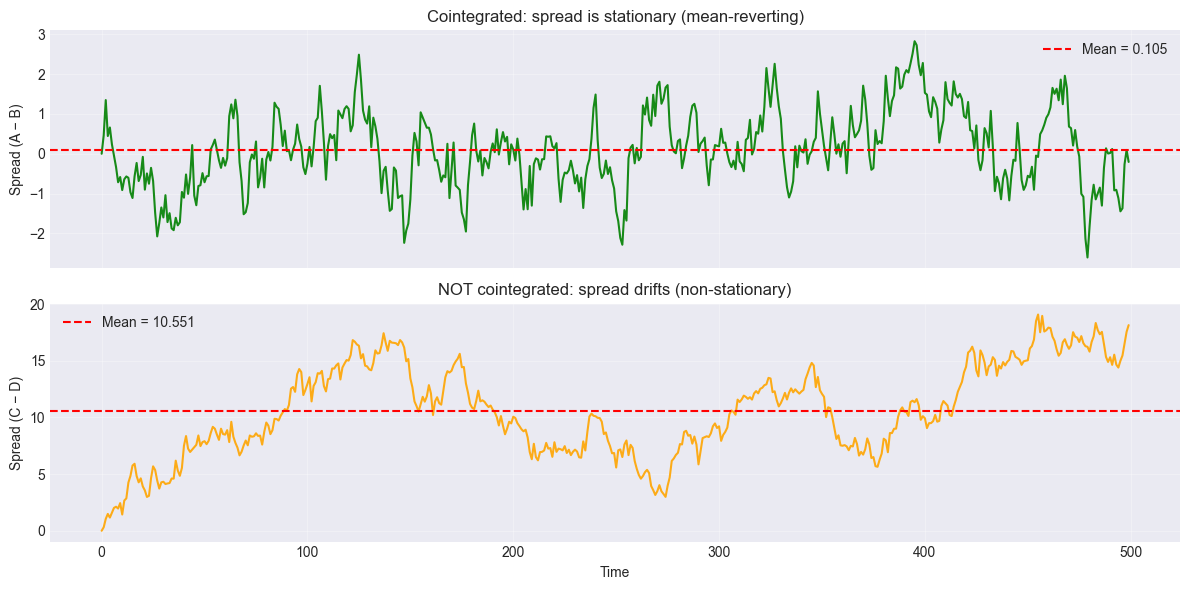

In [57]:
# Graph 2: Spreads — cointegrated spread mean-reverts; non-cointegrated spread drifts
spread_AB = A - B
spread_CD = C - D
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_idx, spread_AB, color='green', alpha=0.9)
axes[0].axhline(spread_AB.mean(), color='red', ls='--', label=f'Mean = {spread_AB.mean():.3f}')
axes[0].set_ylabel('Spread (A − B)')
axes[0].set_title('Cointegrated: spread is stationary (mean-reverting)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_idx, spread_CD, color='orange', alpha=0.9)
axes[1].axhline(spread_CD.mean(), color='red', ls='--', label=f'Mean = {spread_CD.mean():.3f}')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Spread (C − D)')
axes[1].set_title('NOT cointegrated: spread drifts (non-stationary)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

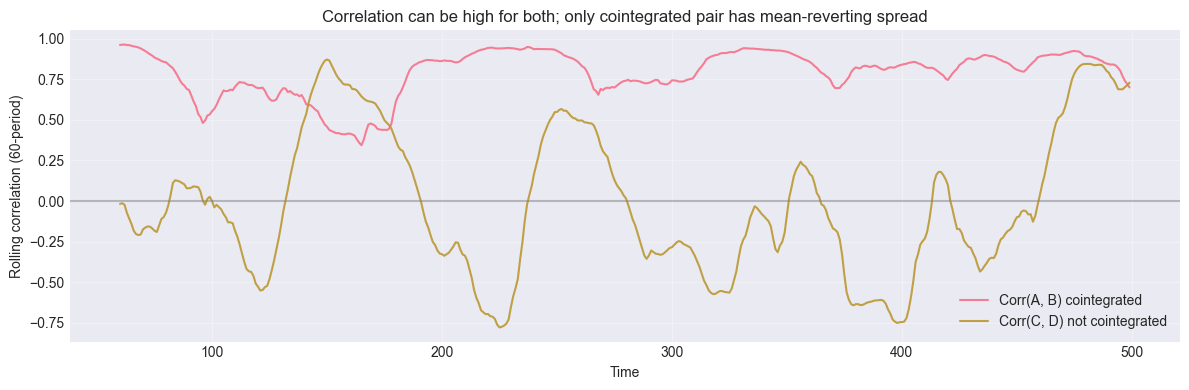

In [58]:
# Graph 3: Rolling correlation — both pairs can show high correlation; correlation ≠ cointegration
window = 60
roll_corr_AB = pd.Series(A).rolling(window).corr(pd.Series(B)).values
roll_corr_CD = pd.Series(C).rolling(window).corr(pd.Series(D)).values
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_idx[window:], roll_corr_AB[window:], label='Corr(A, B) cointegrated', alpha=0.9)
ax.plot(t_idx[window:], roll_corr_CD[window:], label='Corr(C, D) not cointegrated', alpha=0.9)
ax.axhline(0, color='gray', ls='-', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Rolling correlation (60-period)')
ax.set_title('Correlation can be high for both; only cointegrated pair has mean-reverting spread')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Augmented Dickey-Fuller test on spreads:
  Spread A−B (cointegrated):  stat=-6.1107, p-value=0.0000  →  Stationary
  Spread C−D (not coint.):   stat=-2.4035, p-value=0.1408  →  Non-stationary


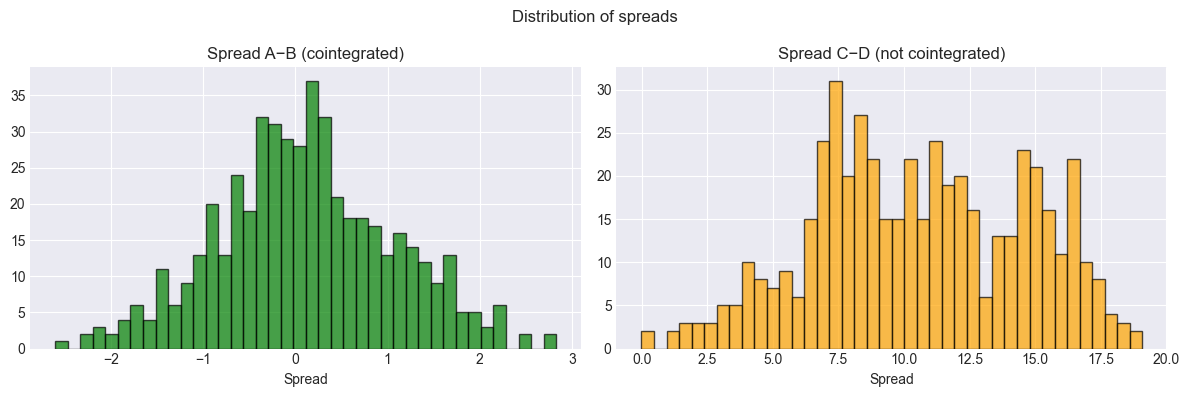

In [59]:
# Graph 4: ADF test on spreads — cointegrated spread is stationary (reject unit root)
try:
    from statsmodels.tsa.stattools import adfuller
    adf_AB = adfuller(spread_AB, autolag='AIC')
    adf_CD = adfuller(spread_CD, autolag='AIC')
    print('Augmented Dickey-Fuller test on spreads:')
    print(f'  Spread A−B (cointegrated):  stat={adf_AB[0]:.4f}, p-value={adf_AB[1]:.4f}  →  {"Stationary" if adf_AB[1] < 0.05 else "Non-stationary"}')
    print(f'  Spread C−D (not coint.):   stat={adf_CD[0]:.4f}, p-value={adf_CD[1]:.4f}  →  {"Stationary" if adf_CD[1] < 0.05 else "Non-stationary"}')
except ImportError:
    print('Install statsmodels for ADF test: pip install statsmodels')
# Histogram of spreads: cointegrated spread centered; non-cointegrated can drift
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(spread_AB, bins=40, color='green', alpha=0.7, edgecolor='k')
axes[0].set_title('Spread A−B (cointegrated)')
axes[0].set_xlabel('Spread')
axes[1].hist(spread_CD, bins=40, color='orange', alpha=0.7, edgecolor='k')
axes[1].set_title('Spread C−D (not cointegrated)')
axes[1].set_xlabel('Spread')
plt.suptitle('Distribution of spreads')
plt.tight_layout()
plt.show()

**Trading implication (longer horizons):** With a **cointegrated** pair (A, B), we can go long one asset and short the other when the spread is above its mean, and expect the spread to revert — so the position is *market-neutral* and profits from mean reversion. With a **correlated but not cointegrated** pair (C, D), the spread can drift without bound; a long-short position may incur large losses. So for **pairs trading** or **relative-value** strategies over longer horizons, we should test for **co-integration** (e.g. Engle-Granger or Johansen), not rely on correlation alone.

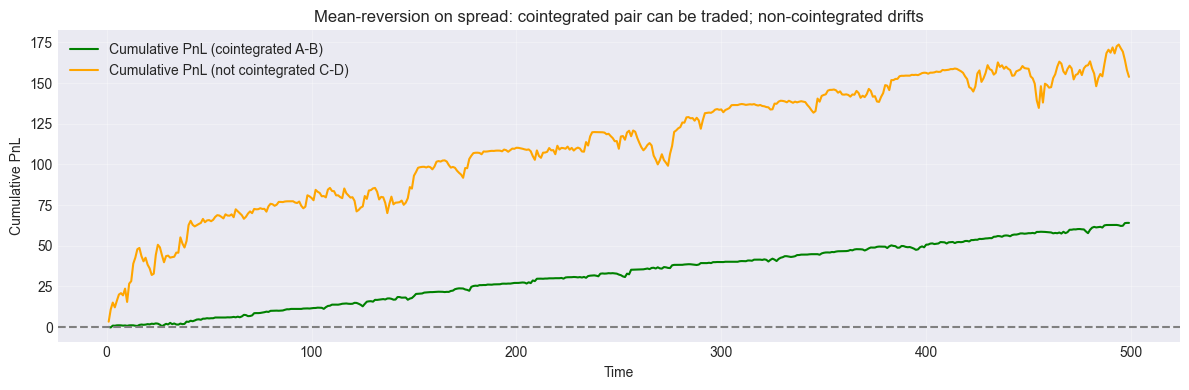

In [60]:
# Graph 5: Simple mean-reversion strategy on spread — works when cointegrated, fails when not
# Strategy: long spread when below mean, short when above (so long A/short B when spread low, etc.)
mean_AB, mean_CD = spread_AB.mean(), spread_CD.mean()
# Returns from mean-reversion: - (spread - mean) * delta(spread) approximates PnL from reversion
delta_AB = np.diff(spread_AB)
delta_CD = np.diff(spread_CD)
# Position: short spread when above mean, long when below
pos_AB = -(spread_AB[:-1] - mean_AB)
pos_CD = -(spread_CD[:-1] - mean_CD)
pnl_AB = pos_AB * delta_AB
pnl_CD = pos_CD * delta_CD
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_idx[1:], np.cumsum(pnl_AB), label='Cumulative PnL (cointegrated A-B)', color='green')
ax.plot(t_idx[1:], np.cumsum(pnl_CD), label='Cumulative PnL (not cointegrated C-D)', color='orange')
ax.axhline(0, color='gray', ls='--')
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative PnL')
ax.set_title('Mean-reversion on spread: cointegrated pair can be traded; non-cointegrated drifts')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Predicting **fret10d** with **features_all** — Linear, Non-linear, and ML

We use **features_crsp** with **features_all** as predictors and **fret10d** as the target. We compare:
1. **Linear regression** — OLS
2. **Non-linear regression** — polynomial features (degree 2)
3. **Machine Learning** — Random Forest and Gradient Boosting

Train/test split is by time (no look-ahead).

In [61]:
features_all

['mom12m',
 'mom6m',
 'rev1m',
 'beta_mktrf',
 'beta_smb',
 'beta_hml',
 'beta_mom',
 'idvar_ff4',
 'iv_atm',
 'put_skew',
 'call_skew',
 'put_skew_rel',
 'call_skew_rel']

In [62]:
# Setup: panel from features_crsp, features_all -> X, fret10d -> y, time-based train/test split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

panel = features_crsp.reset_index() if isinstance(features_crsp.index, pd.MultiIndex) else features_crsp.copy()
feat_cols = [c for c in features_all if c in panel.columns]
panel = panel[feat_cols + ['fret10d', 'date']].dropna()
panel['date'] = pd.to_datetime(panel['date'])
# Time split: last 20% of dates = test
dates_sorted = panel['date'].unique()
split_idx = int(len(dates_sorted) * 0.8)
train_dates, test_dates = dates_sorted[:split_idx], dates_sorted[split_idx:]
train_df = panel[panel['date'].isin(train_dates)]
test_df = panel[panel['date'].isin(test_dates)]
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feat_cols].fillna(0))
X_test = scaler.transform(test_df[feat_cols].fillna(0))
y_train = train_df['fret10d'].values
y_test = test_df['fret10d'].values
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0], "| Features:", len(feat_cols))

Train: 1266933 | Test: 301829 | Features: 13


### 1. Linear regression

**Model:** \(y = X\beta + \varepsilon\). OLS minimizes sum of squared residuals. Interpretable coefficients; assumes linear relationship.

Linear R² train: 0.0105  test: -0.0092


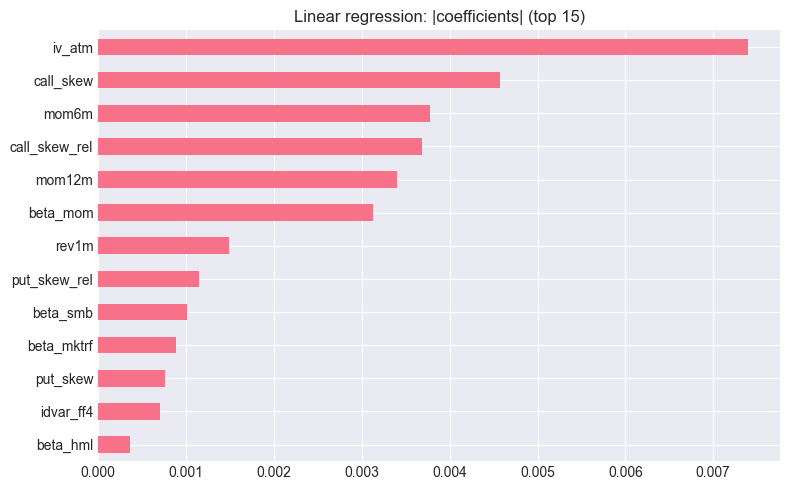

In [63]:
# Linear: OLS
model_linear = LinearRegression().fit(X_train, y_train)
y_train_pred_lin = model_linear.predict(X_train)
y_test_pred_lin = model_linear.predict(X_test)
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)
print(f"Linear R² train: {r2_train_lin:.4f}  test: {r2_test_lin:.4f}")
# Plot: coefficient magnitudes (top 15)
coef = pd.Series(model_linear.coef_, index=feat_cols).abs().sort_values(ascending=True).tail(15)
coef.plot(kind='barh', figsize=(8, 5), title='Linear regression: |coefficients| (top 15)')
plt.tight_layout()
plt.show()

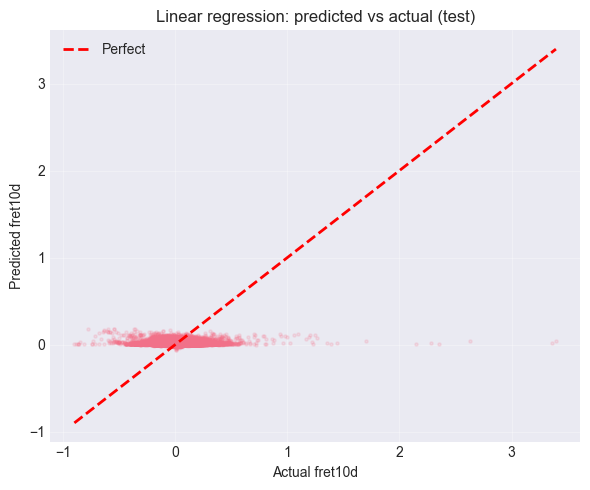

In [64]:
# Predicted vs actual (test set) — Linear
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_test_pred_lin, alpha=0.15, s=5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual fret10d'); ax.set_ylabel('Predicted fret10d')
ax.set_title('Linear regression: predicted vs actual (test)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Non-linear regression

**Model:** We add **polynomial features** (e.g. degree 2: \(x_i, x_i^2, x_i x_j\)) so the model can capture curvature and interactions while still fitting with linear regression on the expanded design matrix.

In [65]:
# Non-linear: polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model_poly = LinearRegression().fit(X_train_poly, y_train)
y_train_pred_poly = model_poly.predict(X_train_poly)
y_test_pred_poly = model_poly.predict(X_test_poly)
r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)
print(f"Polynomial (deg=2) R² train: {r2_train_poly:.4f}  test: {r2_test_poly:.4f}")
print("Number of polynomial features:", X_train_poly.shape[1])

Polynomial (deg=2) R² train: 0.0232  test: -0.0310
Number of polynomial features: 104


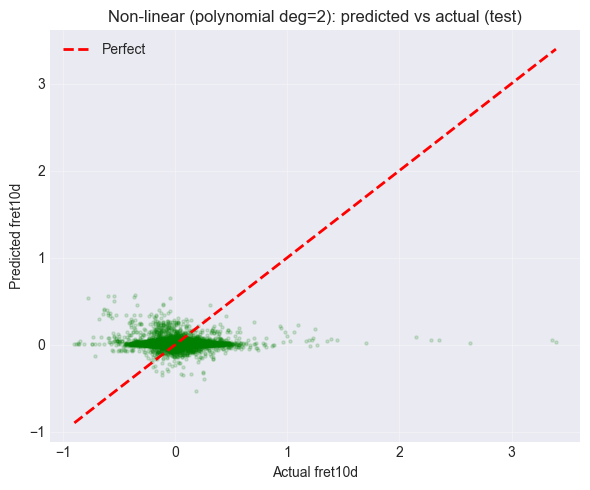

In [66]:
# Predicted vs actual (test) — Polynomial
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_test_pred_poly, alpha=0.15, s=5, color='green')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual fret10d'); ax.set_ylabel('Predicted fret10d')
ax.set_title('Non-linear (polynomial deg=2): predicted vs actual (test)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Machine Learning

**Models:** **Random Forest** (ensemble of trees; robust, handles non-linearity) and **Gradient Boosting** (sequential trees minimizing residuals). No need to specify functional form; can capture complex interactions.

In [67]:
# ML: Random Forest and Gradient Boosting (modest size for speed)
model_rf = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
model_gb = GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=42)
model_rf.fit(X_train, y_train)
model_gb.fit(X_train, y_train)
y_test_pred_rf = model_rf.predict(X_test)
y_test_pred_gb = model_gb.predict(X_test)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
r2_test_gb = r2_score(y_test, y_test_pred_gb)
print(f"Random Forest  R² test: {r2_test_rf:.4f}")
print(f"Gradient Boost R² test: {r2_test_gb:.4f}")

Random Forest  R² test: -0.0185
Gradient Boost R² test: -0.0351


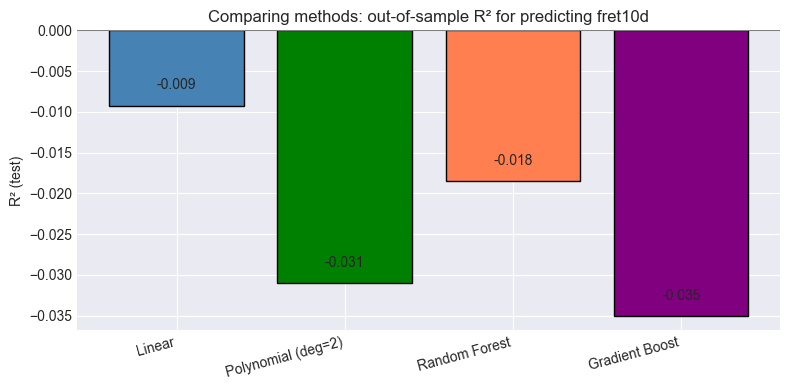

In [68]:
# Bar chart: R² (test) for all methods
methods = ['Linear', 'Polynomial (deg=2)', 'Random Forest', 'Gradient Boost']
r2_scores = [r2_test_lin, r2_test_poly, r2_test_rf, r2_test_gb]
colors = ['steelblue', 'green', 'coral', 'purple']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(methods, r2_scores, color=colors, edgecolor='k')
ax.axhline(0, color='gray', ls='-')
ax.set_ylabel('R² (test)')
ax.set_title('Comparing methods: out-of-sample R² for predicting fret10d')
for b, v in zip(bars, r2_scores):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002, f'{v:.3f}', ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

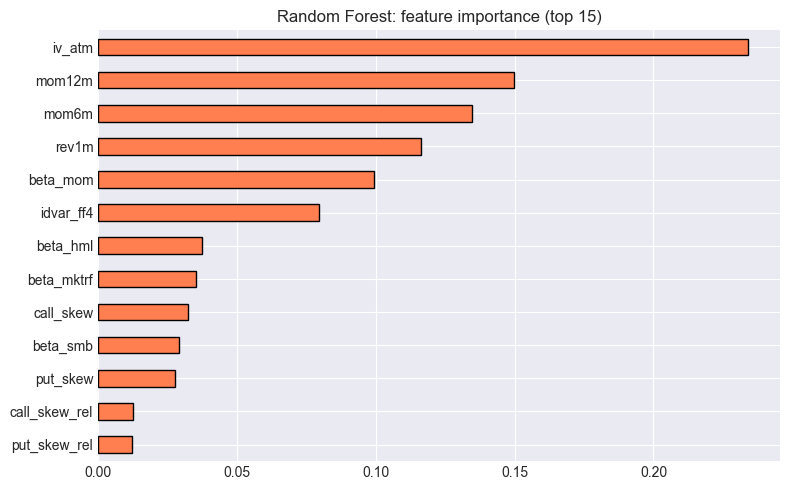

In [69]:
# Feature importance (Random Forest) — which features_all matter most?
imp = pd.Series(model_rf.feature_importances_, index=feat_cols).sort_values(ascending=True).tail(15)
imp.plot(kind='barh', figsize=(8, 5), title='Random Forest: feature importance (top 15)', color='coral', edgecolor='k')
plt.tight_layout()
plt.show()

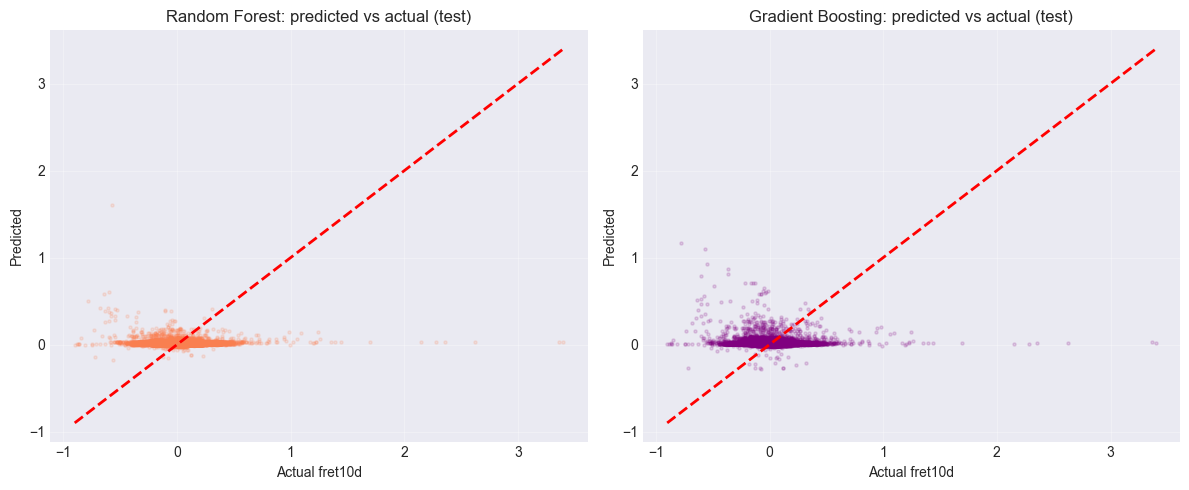

In [70]:
# Predicted vs actual (test) — Random Forest and Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_test_pred_rf, alpha=0.15, s=5, color='coral')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual fret10d'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Random Forest: predicted vs actual (test)')
axes[0].grid(True, alpha=0.3)
axes[1].scatter(y_test, y_test_pred_gb, alpha=0.15, s=5, color='purple')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual fret10d'); axes[1].set_ylabel('Predicted')
axes[1].set_title('Gradient Boosting: predicted vs actual (test)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Recap:** Linear regression gives interpretable coefficients and a baseline. Non-linear (polynomial) adds curvature and interactions. ML (RF, GBM) can capture more complex patterns but may overfit — always compare **test** R². For predicting **fret10d** with **features_all**, students can extend this with cross-validation, more ML models, or regularization (Ridge/Lasso).